**Background**

The goal of this project is to inform a friend who owns a small business about the online shopping market for espresso cups. I used multiple OLS regression to determine which characteristics are associated with the sales rate of a product.

**Uses**

This information is useful for two distinct purposes. The first is that for those variables which are plausibly unbiased we can consider changing the product to increase sales. For example, the number of color palettes is positively related to sales so it is possible that offering more colors of the product will increase sales.

The second purpose in understanding the prevalence of certain characteristics in the market is for the differentiation of the product. Knowing how our product differs from the most common products may imply that marketing should emphasize these differences. For example, the findings of this analysis indicate that most of the sales consist of products that are porcelain and include saucers. On the other hand Piccolo Forte's [Product](https://www.amazon.com/Espresso-Machiato-Cortado-Capuccino-Piccolo/dp/B0F6VFLKTT) is sleek and in style. Advertisments emphasizing the fact that our cups serve as a desirable alternative to these others may be effective.

A dashboard was made alongside this project [here](https://public.tableau.com/app/profile/ruskin.nohe.moren/viz/Whatarepopularespressocupslike/Dashboard1).

In [71]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
import scipy.stats as stats

In [72]:
data = pd.read_csv(r'/content/Amazon Espresso Cup Search - Sheet1.csv')

In [73]:
#Define Variables:
#Numeric encoding for material category
data['Material_cat'] = data['Material']
data['Material_cat'] = 0
data.loc[data['Material'] == 'Porcelain', 'Material_cat'] = 1
data.loc[data['Material'] == 'Stoneware', 'Material_cat'] = 2

In [74]:
#Define Variables:
#Dummy Variable for Products that include both Saucers and a rack for the cups
data['saucer_and_rack'] = 0
data.loc[((data['Saucer'] == 1) & (data['Rack'] == 1)), 'saucer_and_rack'] = 1

In [75]:
#Dummy indicating weather the product has 1 or > 1 color palette options
data['multi_palettes'] = 0
data.loc[data['# of color palletes'] > 1, 'multi_palettes'] = 1

In [76]:
#More Calculated Variables:
data['Review_Rate'] = (data['# of reviews']/data['#_Days_Listed'])
#log transformation since raw data was non-normal and normality given betas is an OLS assumption
data['log price per count'] = np.log(data['Price per count'])
data['log_count'] = np.log(data['Count'])
data['log #_Days_Listed'] = np.log(data['#_Days_Listed'])
data['log_review_rate'] = np.log(data['Review_Rate'])
data['log # of reviews'] = np.log(data['# of reviews'])

#The distribution of ratings has a large count at the lower end so we need to normalize it
#flip the distribution so that lower ratings are largest by subtracting from 5.1, then take the log and it approximates a normal distribution
data['inverse_rating'] = np.log(5.1 - data['rating'])

In [ ]:
#data.head()
#this output breaks the github preview since it is too wide, that's why it's hashed out

,Price per count,Count,# of color palletes,# of reviews,rating,Restaurant|Cafe|Coffee_Shop,Material,Porcelain_Emphasized,#_Days_Listed,Saucer,...,Material_cat,saucer_and_rack,multi_palettes,Review_Rate,log price per count,log_count,log #_Days_Listed,log_review_rate,log # of reviews,inverse_rating
0,4.50,4,1,93,4.6,0,Ceramic,0,1075,0,...,0,0,0,0.086512,1.504077,1.386294,6.980076,-2.447476,4.532599,-0.693147
1,4.50,4,1,35,4.8,1,Ceramic,0,267,0,...,0,0,0,0.131086,1.504077,1.386294,5.587249,-2.031901,3.555348,-1.203973
2,7.50,4,1,28,4.5,0,Ceramic,0,576,0,...,0,0,0,0.048611,2.014903,1.386294,6.356108,-3.023903,3.332205,-0.510826
3,9.99,1,12,24,4.2,0,Ceramic,0,550,0,...,0,0,1,0.043636,2.301585,0.000000,6.309918,-3.131864,3.178054,-0.105361
4,2.83,6,1,471,4.8,0,Porcelain,1,657,0,...,1,0,0,0.716895,1.040277,1.791759,6.487684,-0.332826,6.154858,-1.203973


In [78]:
#descriptive statistics for continuous variables
data[['Count', '# of color palletes', 'Review_Rate', 'Price per count', '#_Days_Listed', 'rating']].describe()

,Count,# of color palletes,Review_Rate,Price per count,#_Days_Listed,rating
count,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000
mean,4.023810,3.369048,0.419988,7.271310,853.011905,4.601190
std,2.832582,2.907323,0.720536,4.545657,708.668725,0.231545
min,1.000000,1.000000,0.005673,1.670000,72.000000,3.800000
25%,2.000000,1.000000,0.077302,4.745000,368.250000,4.500000
50%,4.000000,2.000000,0.195234,6.000000,722.000000,4.650000
75%,4.000000,5.250000,0.469982,8.365000,1079.000000,4.800000
max,24.000000,12.000000,4.726619,29.990000,4020.000000,5.000000


In [79]:
#descriptive statistics for binary variables
data[['multi_palettes', 'Saucer', 'Rack', 'Porcelain_Emphasized']].describe()

,multi_palettes,Saucer,Rack,Porcelain_Emphasized
count,84.000000,84.000000,84.000000,84.000000
mean,0.619048,0.357143,0.178571,0.380952
std,0.488538,0.482035,0.385293,0.488538
min,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000
50%,1.000000,0.000000,0.000000,0.000000
75%,1.000000,1.000000,0.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000


In [102]:
#sample proportions of Materials
data['Material'].value_counts(normalize=True)

,proportion
Material,
Porcelain,0.476190
Ceramic,0.464286
Stoneware,0.059524


In [80]:
Porcelain = data[data['Material'] == 'Porcelain']
Ceramic = data[data['Material'] == 'Ceramic']

<Axes: xlabel='Material', ylabel='log_review_rate'>

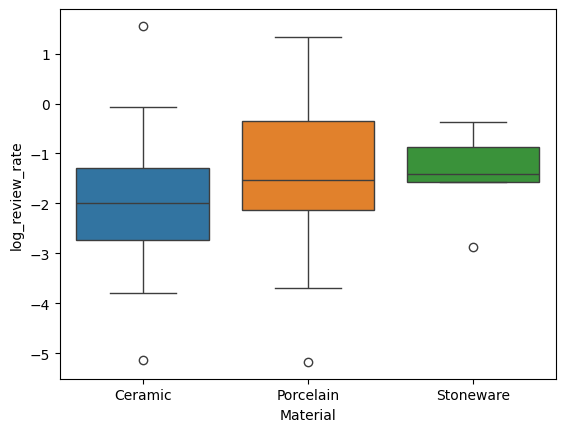

In [81]:
#Data vizualisations of the log review rate by various categories:
sns.boxplot(data=data, x='Material', y='log_review_rate', hue='Material')

<Axes: xlabel='Material', ylabel='log price per count'>

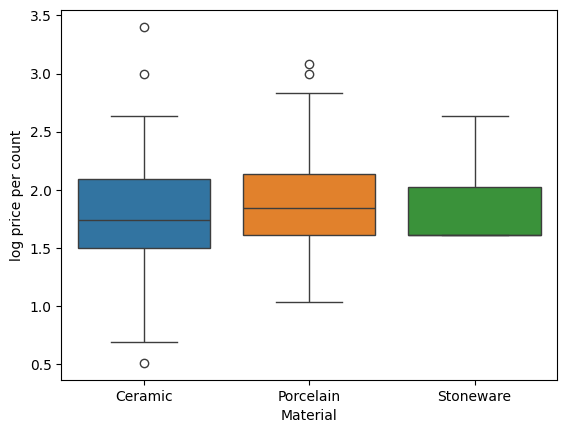

In [82]:
sns.boxplot(data=data, x='Material', y='log price per count', hue='Material')

<Axes: xlabel='Porcelain_Emphasized', ylabel='log_review_rate'>

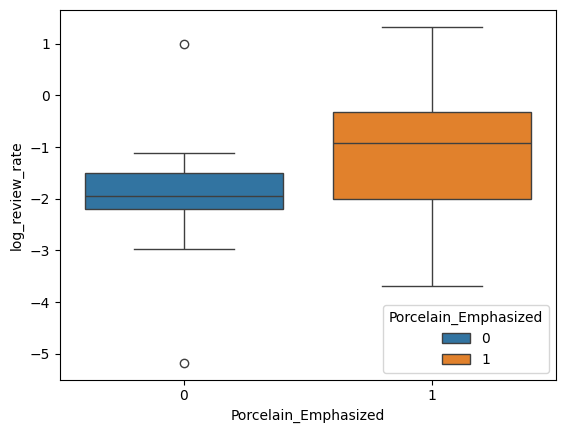

In [83]:
sns.boxplot(data=Porcelain, x='Porcelain_Emphasized', y='log_review_rate', hue='Porcelain_Emphasized')

<Axes: xlabel='Porcelain_Emphasized', ylabel='log price per count'>

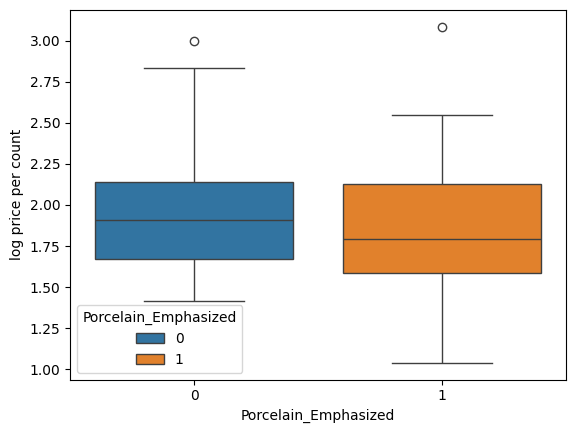

In [84]:
sns.boxplot(data=Porcelain, x='Porcelain_Emphasized', y='log price per count', hue='Porcelain_Emphasized')

<Axes: xlabel='saucer_and_rack', ylabel='log # of reviews'>

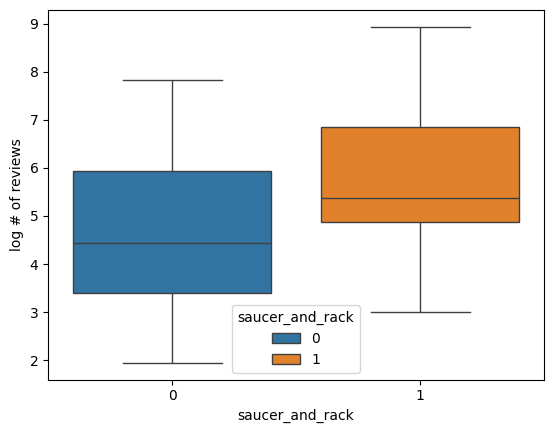

In [85]:
sns.boxplot(data=data, x='saucer_and_rack', y='log # of reviews', hue='saucer_and_rack')

<Axes: xlabel='saucer_and_rack', ylabel='log price per count'>

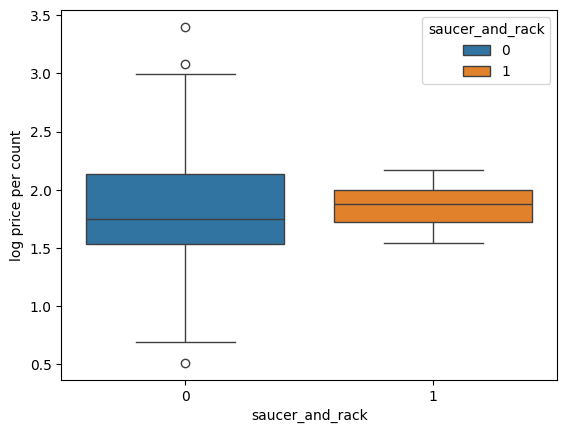

In [86]:
sns.boxplot(data=data, x='saucer_and_rack', y='log price per count', hue='saucer_and_rack')

<Figure size 650x650 with 0 Axes>

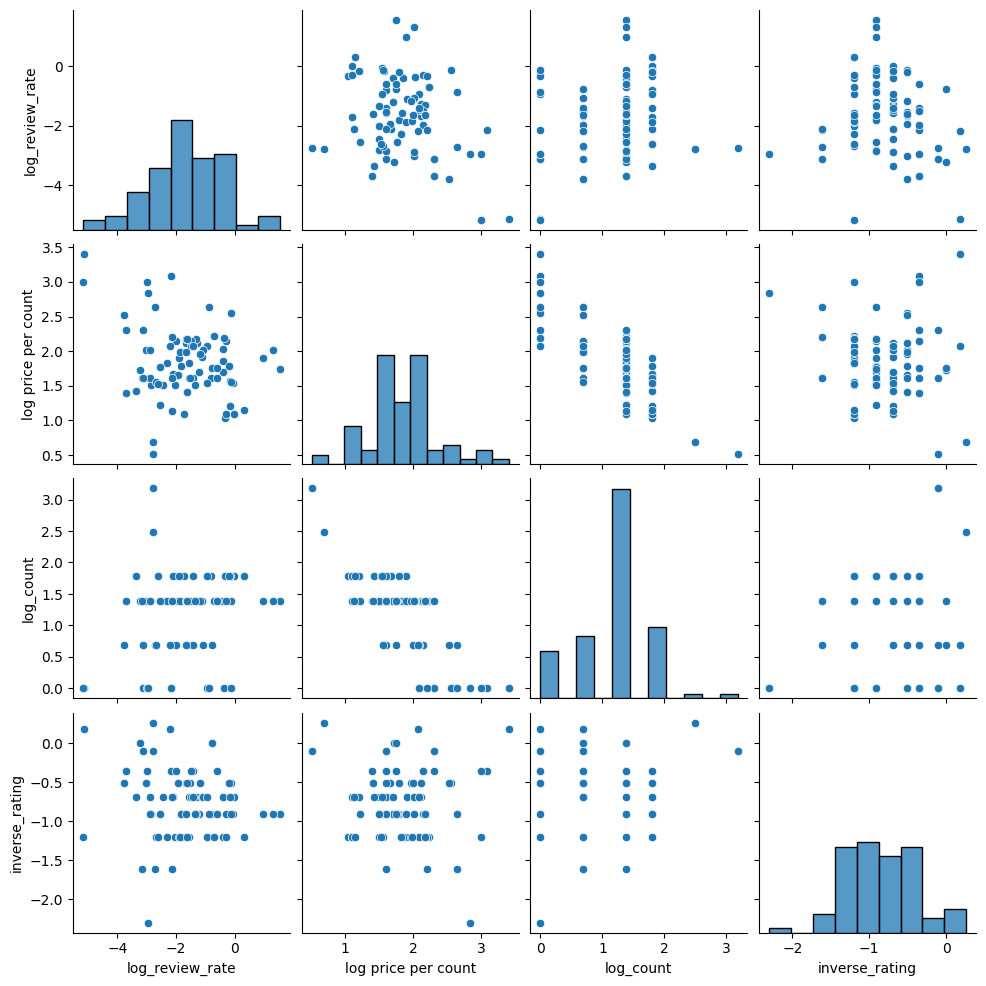

In [ ]:
#plt.figure(figsize=(6.5,6.5))
#sns.pairplot(data[['log_review_rate', 'log price per count', 'log_count', 'inverse_rating']])

#this output breaks the github preview since it is too wide, that's why the code is hashed out

In [88]:
from statsmodels.formula.api import ols
#Rename variables so they do not have spaces since spaces do not work with statsmodels OLS

data.rename(columns={'log price per count':'log_price_per_count',
                     'log #_Days_Listed': 'log_Days_Listed',
                     'log price per count': 'log_price_per_count',
                     'log # of reviews': 'log_reviews',
                     '# of color palletes': 'color_palettes'
                     }, inplace=True)
Porcelain.rename(columns={'log price per count':'log_price_per_count',
                     'log #_Days_Listed': 'log_Days_Listed',
                     'log price per count': 'log_price_per_count',
                     'log # of reviews': 'log_reviews'
                     }, inplace=True)

/tmp/ipython-input-785375262.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Porcelain.rename(columns={'log price per count':'log_price_per_count',


In [89]:
#check for outliers of 'log review rate'
lower_quantile = np.quantile(data['log_review_rate'], .25)
upper_quantile = np.quantile(data['log_review_rate'], .75)
iqr = upper_quantile - lower_quantile
lower_bound = lower_quantile - (1.5 * iqr)
upper_bound = upper_quantile + (1.5 * iqr)
print(lower_bound, upper_bound)
data[data['log_review_rate'] <= lower_bound]
#The empty dataframe indicates there are no outliers (based on the 1.5 * the interquartile range definition)

-5.2678328992780745 1.9519049920336442


,Price per count,Count,color_palettes,# of reviews,rating,Restaurant|Cafe|Coffee_Shop,Material,Porcelain_Emphasized,#_Days_Listed,Saucer,...,Material_cat,saucer_and_rack,multi_palettes,Review_Rate,log_price_per_count,log_count,log_Days_Listed,log_review_rate,log_reviews,inverse_rating


In [90]:
formula = 'log_review_rate ~ multi_palettes + Saucer + I(inverse_rating**2) + inverse_rating + log_price_per_count + I(log_price_per_count**2)'
OLS = ols(formula=formula, data=data)
model=OLS.fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:        log_review_rate   R-squared:                       0.345
Model:                            OLS   Adj. R-squared:                  0.294
Method:                 Least Squares   F-statistic:                     6.762
Date:                Mon, 18 Aug 2025   Prob (F-statistic):           8.79e-06
Time:                        02:15:03   Log-Likelihood:                -121.46
No. Observations:                  84   AIC:                             256.9
Df Residuals:                      77   BIC:                             273.9
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept         

The coefficients of interest in the above model are for the dummies indicating whether the product includes Saucers and more than one color palette options ("multi_palettes").

Because the dependent variable is log-transformed, the coefficients indicate that, on average, products with multiple palettes have 88% (1 - e^0.63) higher review rate than those with only one, and products with saucers have 77% (1-e^0.57) higher sales rate than those that do not.

In [91]:
#check for multicollinearity
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
VIF = data[['multi_palettes', 'Saucer', 'inverse_rating', 'log_price_per_count']]
X = add_constant(VIF)
X = pd.DataFrame(data=X)
pd.Series([variance_inflation_factor(X.values, i) for i in range(X.shape[1])], index=X.columns)
#no multicollinearity

,0
const,17.500775
multi_palettes,1.066281
Saucer,1.087382
inverse_rating,1.034830
log_price_per_count,1.099192


In [92]:
formula2 = 'log_review_rate ~ I(inverse_rating**2) + inverse_rating + log_price_per_count + I(log_price_per_count**2) + C(Material_cat)'
OLS2 = ols(formula=formula2, data=data)
model2=OLS2.fit()
print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:        log_review_rate   R-squared:                       0.293
Model:                            OLS   Adj. R-squared:                  0.238
Method:                 Least Squares   F-statistic:                     5.330
Date:                Mon, 18 Aug 2025   Prob (F-statistic):           0.000121
Time:                        02:15:03   Log-Likelihood:                -124.65
No. Observations:                  84   AIC:                             263.3
Df Residuals:                      77   BIC:                             280.3
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept         

The coefficient of interest in the above model is for the categorical variable indicating the material of the cup.

On average, porcelain cups have 70% (1-e^0.53) higher review rates.

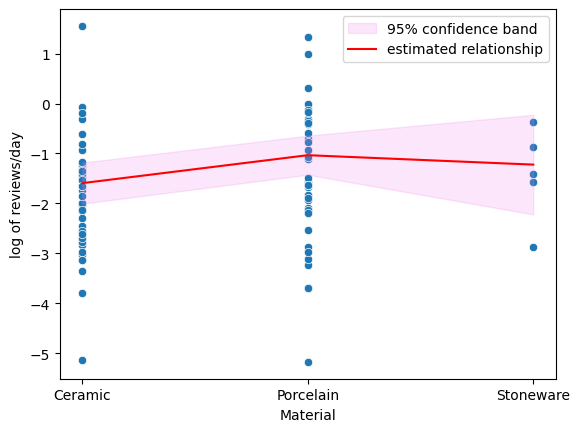

In [103]:
#vizualisation of the estimated relationship
range_x = np.array([0, 1, 2])
prediction_df = pd.DataFrame({'Material_cat': range_x, 'log_price_per_count': data['log_price_per_count'].mean(), 'inverse_rating': data['inverse_rating'].mean()})
sns.scatterplot(data=data, x='Material_cat', y='log_review_rate', )
plt.xticks([0, 1, 2], ['Ceramic', 'Porcelain', 'Stoneware'])
plt.xlabel('Material')
plt.ylabel('log of reviews/day')
predictions = model2.get_prediction(prediction_df)
confidence_interval = predictions.conf_int(alpha=0.05)
plt.fill_between(range_x, confidence_interval[:, 0], confidence_interval[:, 1], color='violet', alpha=0.2, label='95% confidence band')
sns.lineplot(x=range_x, y=model2.predict(prediction_df), color='red', label='estimated relationship')
plt.legend()
plt.show()

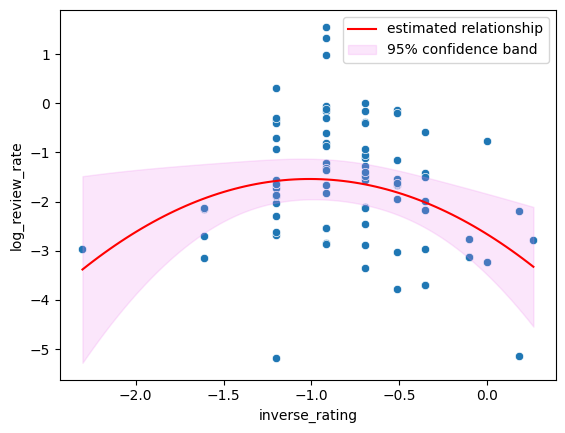

In [104]:
#defined a funciton that vizualises the estimated relationship versus the data in a given model
def _1paribus_viz(x, y, model, dat, cov):
  range_x=np.linspace(start=dat[x].min(), stop=data[x].max(), num=84)
  prediction_df = pd.DataFrame({x: range_x, cov[0]: dat[cov[0]].mean(), cov[1]: 0})
  sns.scatterplot(data=dat, x=x, y=y)
  predictions = model.get_prediction(prediction_df)
  confidence_interval = predictions.conf_int(alpha=0.05)
  sns.lineplot(x=range_x, y=model.predict(prediction_df), color='red', label='estimated relationship')
  plt.fill_between(range_x, confidence_interval[:, 0], confidence_interval[:, 1], color='violet', alpha=0.2, label='95% confidence band')
  plt.legend()
  return plt.show()
_1paribus_viz('inverse_rating', 'log_review_rate', model2, dat=data, cov=['log_price_per_count', 'Material_cat'])

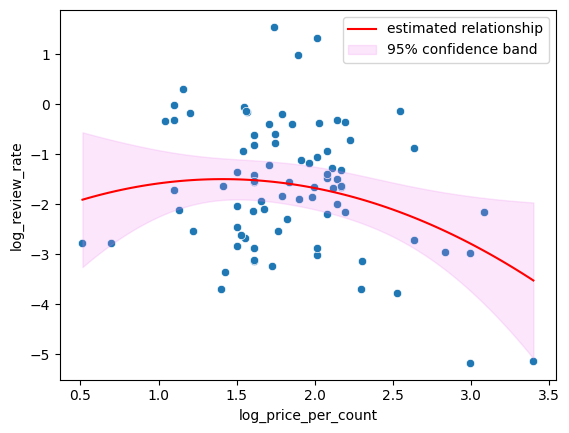

In [105]:
_1paribus_viz('log_price_per_count', 'log_review_rate', model=model2, dat=data, cov=['inverse_rating', 'Material_cat'])

In [96]:
formula3 = 'log_price_per_count ~ log_review_rate + Saucer + multi_palettes'
OLS3 = ols(formula=formula3, data=data)
model3=OLS3.fit()
model3.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                             OLS Regression Results                            
===============================================================================
Dep. Variable:     log_price_per_count   R-squared:                       0.228
Model:                             OLS   Adj. R-squared:                  0.199
Method:                  Least Squares   F-statistic:                     7.869
Date:                 Mon, 18 Aug 2025   Prob (F-statistic):           0.000115
Time:                         02:15:03   Log-Likelihood:                -50.659
No. Observations:                   84   AIC:                             109.3
Df Residuals:                       80   BIC:                             119.0
Df Model:                            3                                         
Covariance Type:             nonrobust                                         
===================================================================================
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           1.2936      0.125     10.330      0.000       1.044       1.543
log_review_rate    -0.1558      0.041     -3.779      0.000      -0.238      -0.074
Saucer              0.2772      0.106      2.613      0.011       0.066       0.488
multi_palettes      0.3176      0.106      2.999      0.004       0.107       0.528
==============================================================================
Omnibus:                        2.758   Durbin-Watson:                   2.122
Prob(Omnibus):                  0.252   Jarque-Bera (JB):                2.372
Skew:                           0.136   Prob(JB):                        0.305
Kurtosis:                       3.777   Cond. No.                         7.21
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

This regression estimates the determinants of price, rather than review rate (approximation of sales rate). The material and other variables were not included since they were not individually significant.

<Axes: xlabel='log reviews/day', ylabel='log price'>

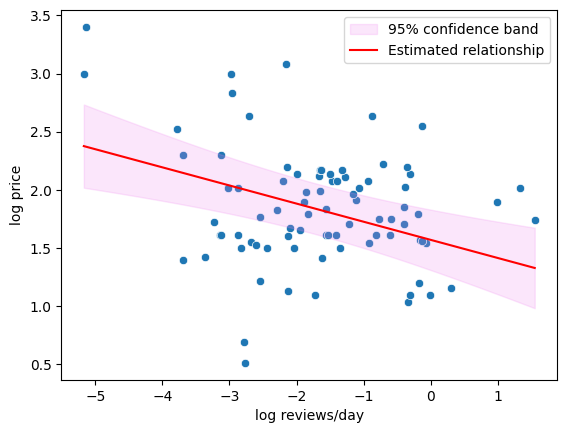

In [97]:
range_x = np.linspace(start=data['log_review_rate'].min(), stop=data['log_review_rate'].max(), num=84)
prediction_df = pd.DataFrame({'log_review_rate': range_x, 'Saucer': 1, 'multi_palettes': 0})
sns.scatterplot(data=data, x='log_review_rate', y='log_price_per_count', )
plt.xlabel('log reviews/day')
plt.ylabel('log price')
predictions = model3.get_prediction(prediction_df)
confidence_interval = predictions.conf_int(alpha=0.05)
plt.fill_between(range_x, confidence_interval[:, 0], confidence_interval[:, 1], color='violet', alpha=0.2, label='95% confidence band')
sns.lineplot(x=range_x, y=model3.predict(prediction_df), color='red', label='Estimated relationship')

In [98]:
formula4 = 'log_review_rate ~ log_price_per_count * C(Material_cat) + inverse_rating + I(inverse_rating**2)'
OLS4 = ols(formula=formula4, data=data)
model4=OLS4.fit()
print(model4.summary())

                            OLS Regression Results                            
Dep. Variable:        log_review_rate   R-squared:                       0.290
Model:                            OLS   Adj. R-squared:                  0.225
Method:                 Least Squares   F-statistic:                     4.433
Date:                Mon, 18 Aug 2025   Prob (F-statistic):           0.000356
Time:                        02:15:04   Log-Likelihood:                -124.86
No. Observations:                  84   AIC:                             265.7
Df Residuals:                      76   BIC:                             285.2
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                                               coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------

In [106]:
formula5 = 'log_review_rate ~ log_price_per_count * Saucer + log_price_per_count * multi_palettes + inverse_rating + I(inverse_rating**2)'
OLS5 = ols(formula=formula5, data=data)
model5=OLS5.fit()
print(model5.summary())

                            OLS Regression Results                            
Dep. Variable:        log_review_rate   R-squared:                       0.364
Model:                            OLS   Adj. R-squared:                  0.305
Method:                 Least Squares   F-statistic:                     6.202
Date:                Mon, 18 Aug 2025   Prob (F-statistic):           9.33e-06
Time:                        03:08:06   Log-Likelihood:                -120.26
No. Observations:                  84   AIC:                             256.5
Df Residuals:                      76   BIC:                             276.0
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                                         coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
Inte

These last two models estimate the interaction of various factors with price. We have found that the material, including a saucer, and including multiple color palettes are all associated with a higher (proxied) rate of sales.

These interactions terms investigate whether the categories change the willingness to pay of customers. Because the relationship between the price and sales is not causal, they don't really test a change in the elasticity of the demand between categories, but it is still useful to test the significance of the interactions to see if the data suggests this possibility. Then a more rigorous investigation into higher willingness to pay for these attributes might have been worthwhile.

However, the information that we do have does not strongly suggest this to be the case as none of the interaction terms are significant.